In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
DATA_DIR = "../data/"

DAYS = [0, 1, 2]

DELTA1 = ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']
UNDERLYING = 'VELVETFRUIT_EXTRACT'
STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VOUCHERS = [f'VEV_{K}' for K in STRIKES]
VOUCHER_STRIKE = {f'VEV_{K}': K for K in STRIKES}

PARMAS = {
    'HYDROGEL_PACK': 
        ema_alpha = 0.05 
    
    
    'VELVETFRUIT_EXTRACT':
        ema_alpha = 0.05
    }

In [31]:

# load prices
prices_frames = []

for day in DAYS:
    prices_frames.append(pd.read_csv(f"{DATA_DIR}prices_round_3_day_{day}.csv", delimiter = ";"))

prices_all = pd.concat(prices_frames, axis = 0, ignore_index = True)

prices_all["time_index"] = prices_all["day"] * 100_000 + prices_all["timestamp"]

vol_cols = [c for c in prices_all.columns if 'volume' in c]
prices_all[vol_cols] = prices_all[vol_cols].fillna(0)

# Drop rows with no mid (one-sided or empty book)
prices_all = prices_all[prices_all['mid_price'] > 0].copy()

# ----- Load trades -----
trades_frames = []
for day in DAYS:
    df = pd.read_csv(f'{DATA_DIR}/trades_round_3_day_{day}.csv', sep=';')
    df['day'] = day
    trades_frames.append(df)
trades_all = pd.concat(trades_frames, ignore_index=True)
trades_all['time_index'] = trades_all['day'] * 1_000_000 + trades_all['timestamp']

print(f'Prices rows: {len(prices_all):,}')
print(f'  Products : {sorted(prices_all["product"].unique().tolist())}')
print(f'  Days     : {sorted(prices_all["day"].unique().tolist())}')
print(f'Trades rows: {len(trades_all):,}')
print(f'  Symbols : {sorted(trades_all["symbol"].unique().tolist())}')
prices_all.head(3)

Prices rows: 360,000
  Products : ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
  Days     : [0, 1, 2]
Trades rows: 4,048
  Symbols : ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,time_index
0,0,0,VEV_5400,22,25,NaN,0.0,NaN,0.0,24,25,NaN,0.0,NaN,0.0,23.0,0.0,0
1,0,0,VEV_6500,0,16,NaN,0.0,NaN,0.0,1,16,NaN,0.0,NaN,0.0,0.5,0.0,0
2,0,0,VEV_5500,8,25,NaN,0.0,NaN,0.0,9,25,NaN,0.0,NaN,0.0,8.5,0.0,0


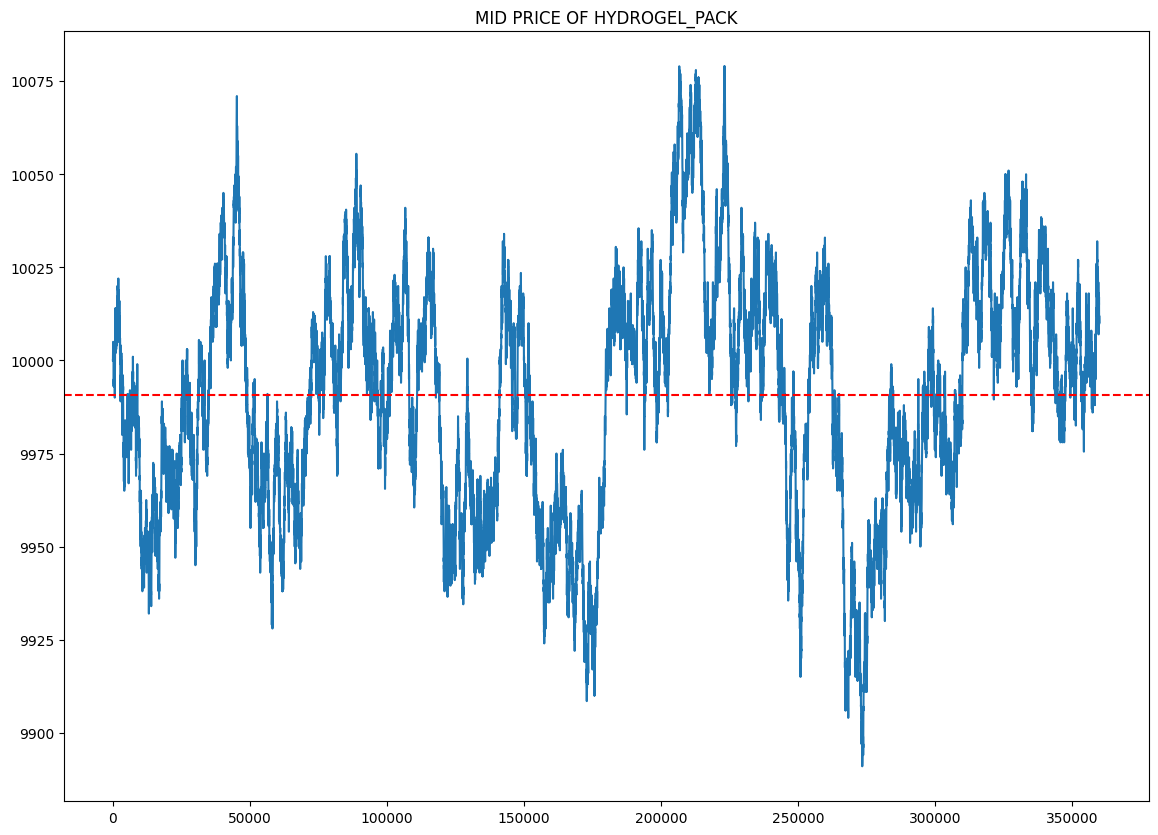

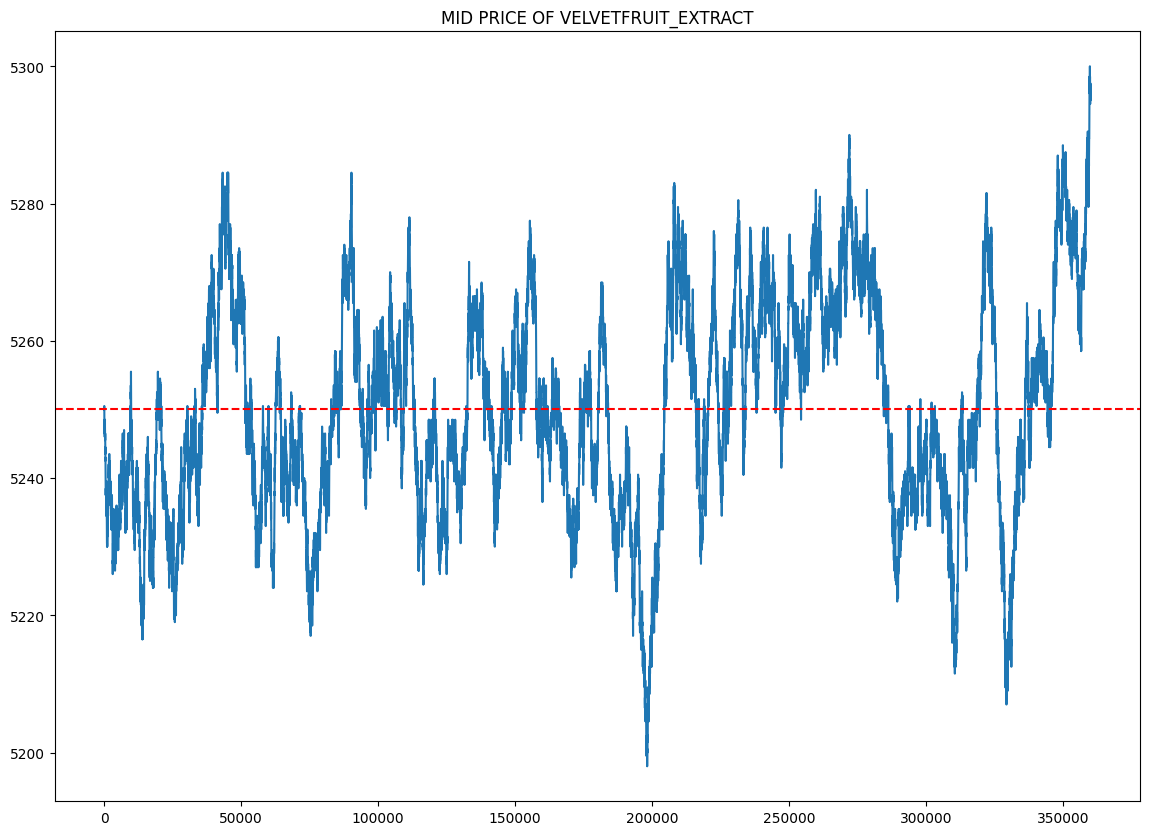

In [ ]:


for d1 in DELTA1:
    ema_alpha = PARAMS[d1].get("ema_alpha", 0.05)
    d1_price = prices_all.loc[prices_all["product"] == d1]
    d1_mid = d1_price["mid_price"]
    d1_mid_avg = d1_mid.mean()
    
    
    
    # plot mid
    fig, ax = plt.subplots(1,1, figsize = (14,10))
    ax.plot(d1_mid, label = f"{d1}: mid price")
    ax.set_title(f"MID PRICE OF {d1}")
    ax.axhline(y= d1_mid_avg, color='red', linestyle='--', linewidth=1.5)

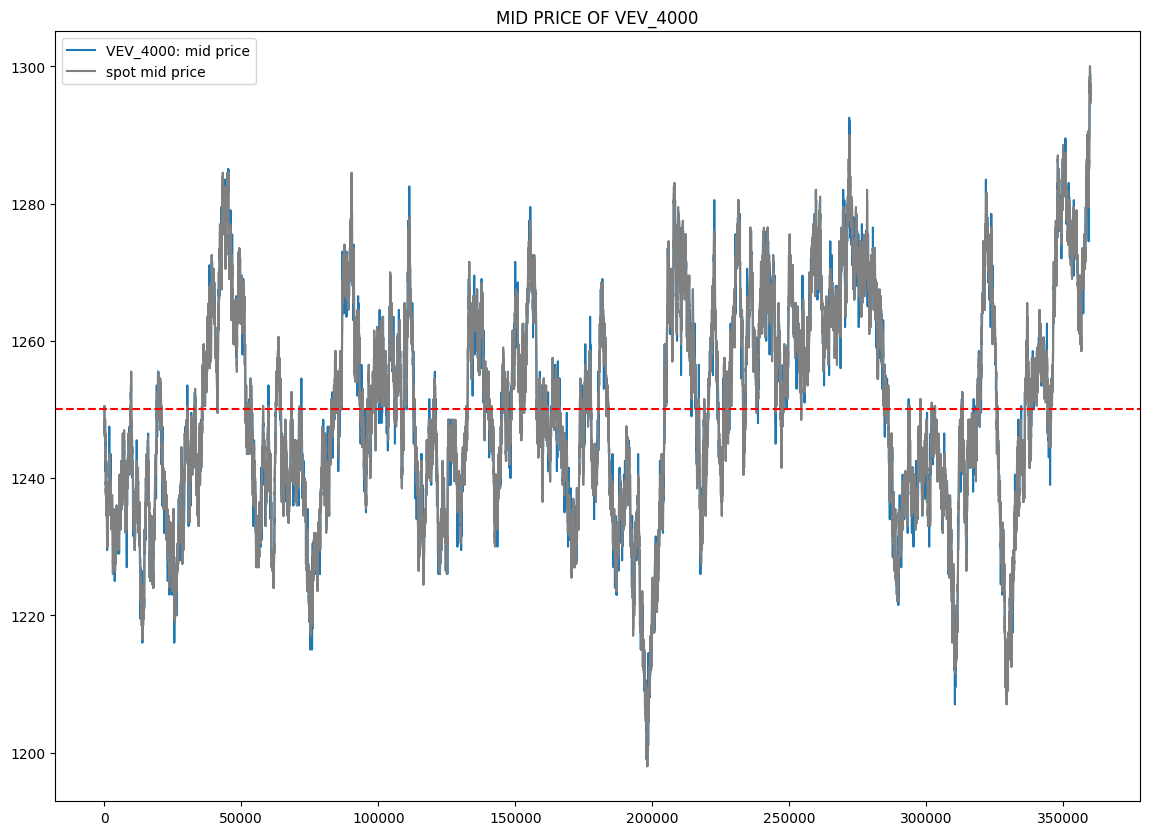

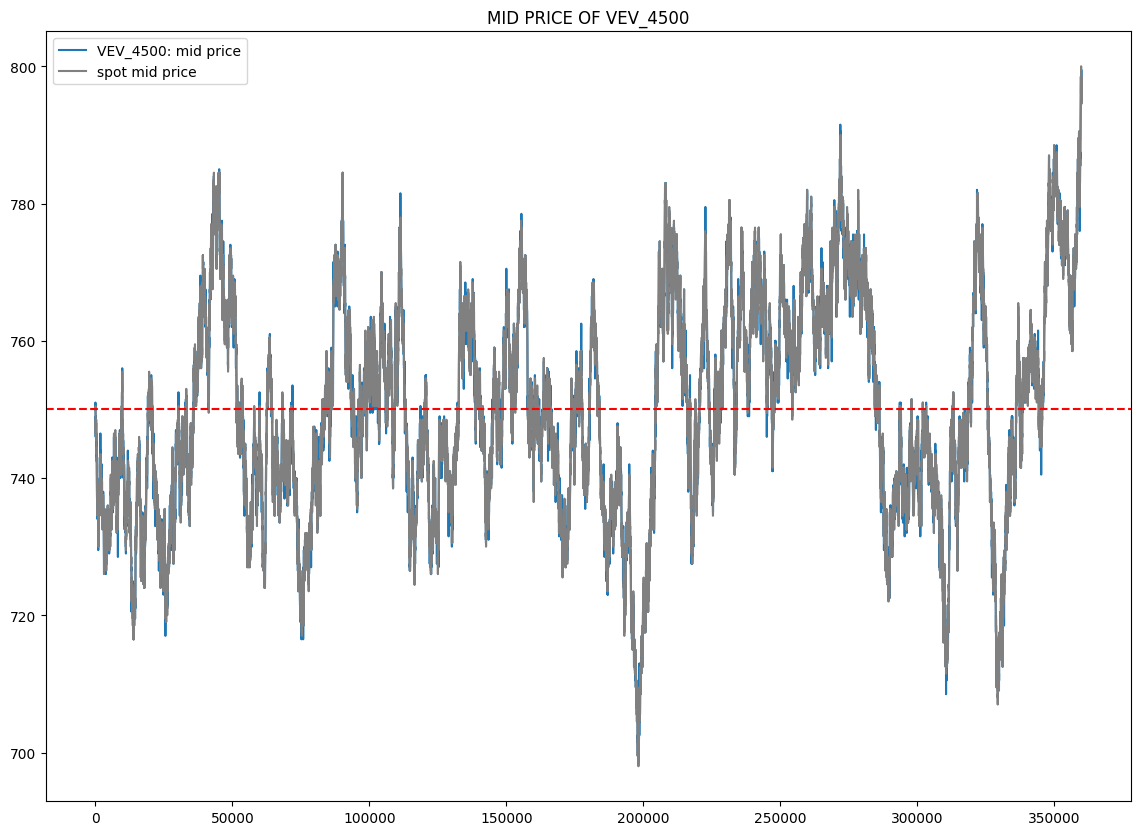

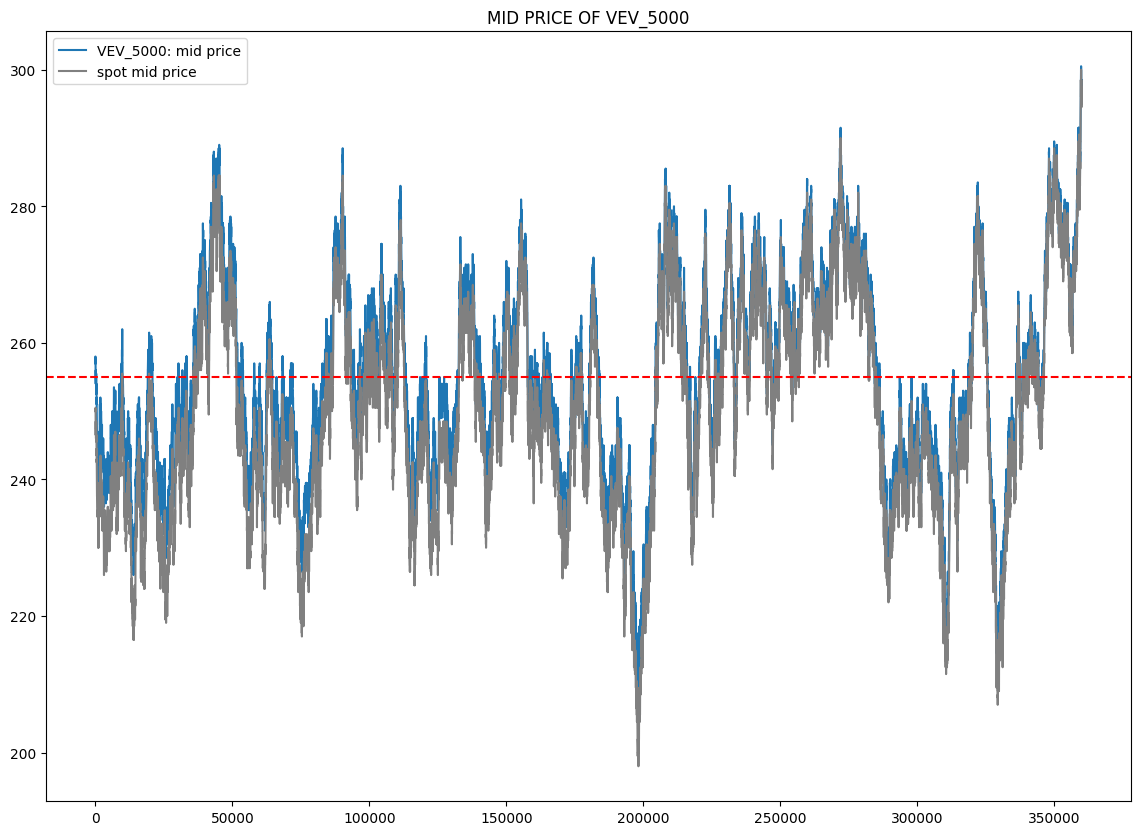

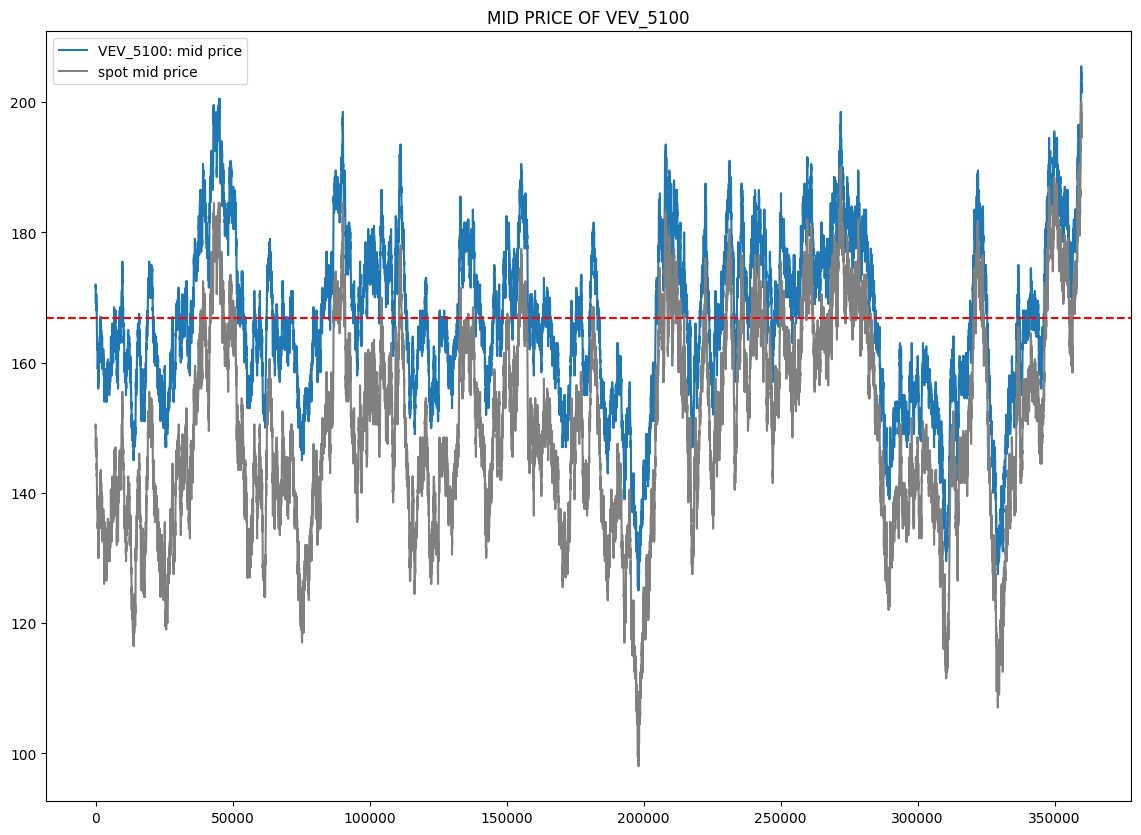

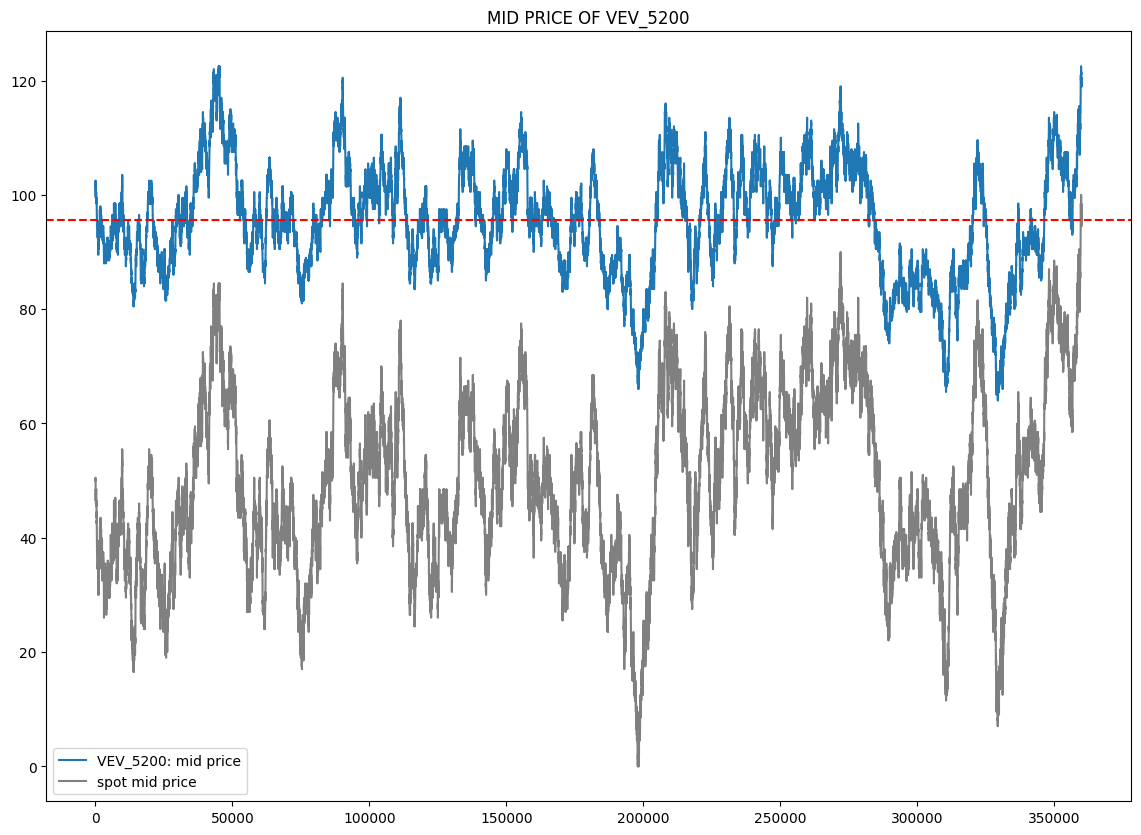

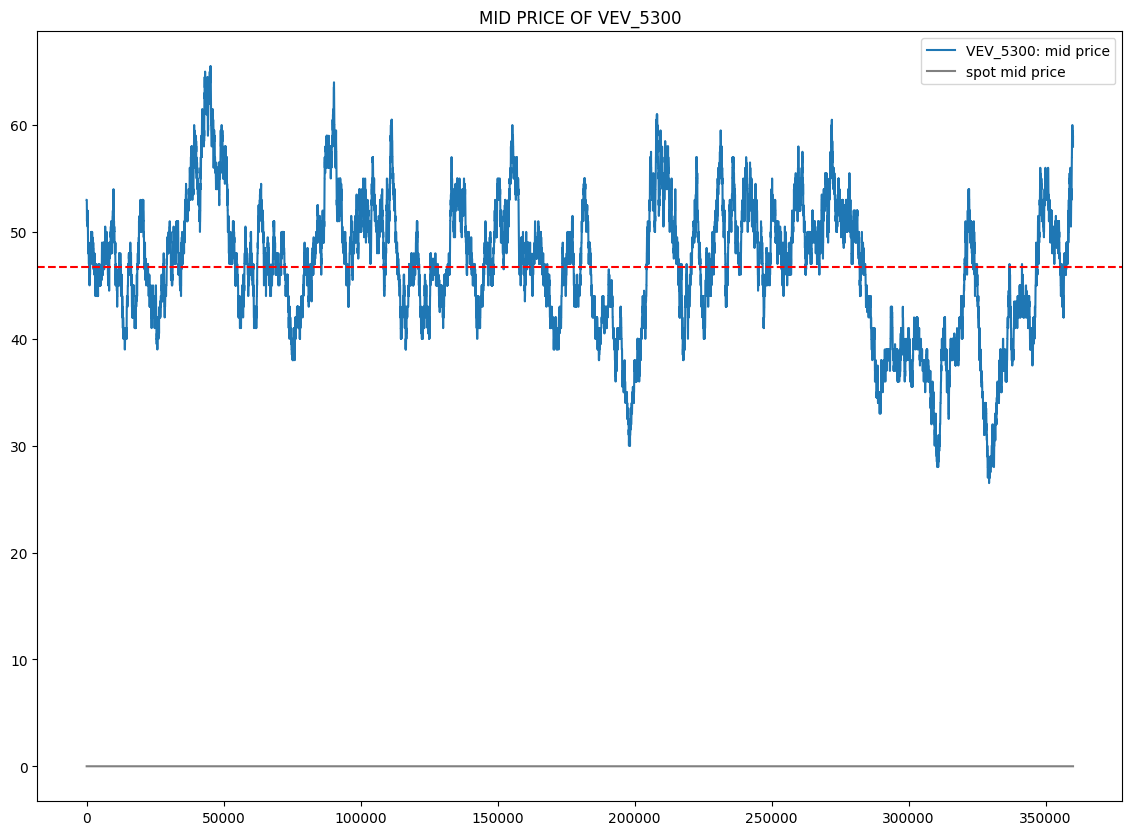

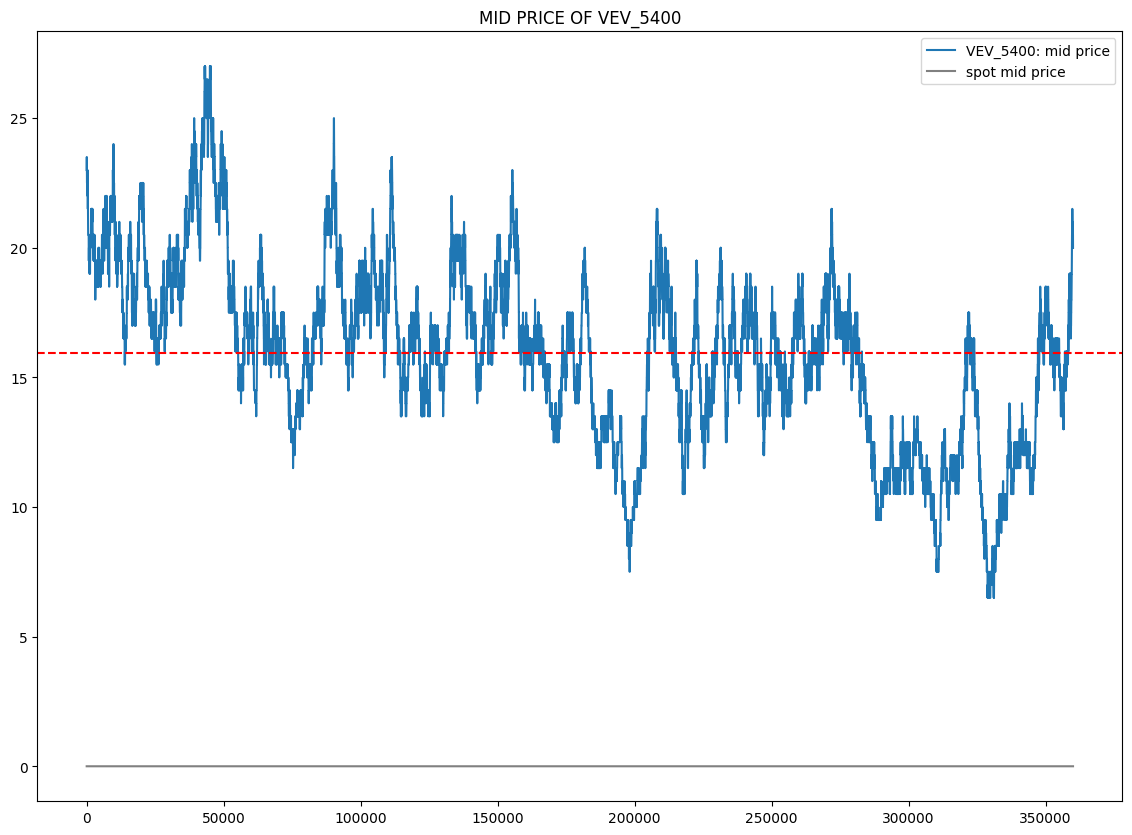

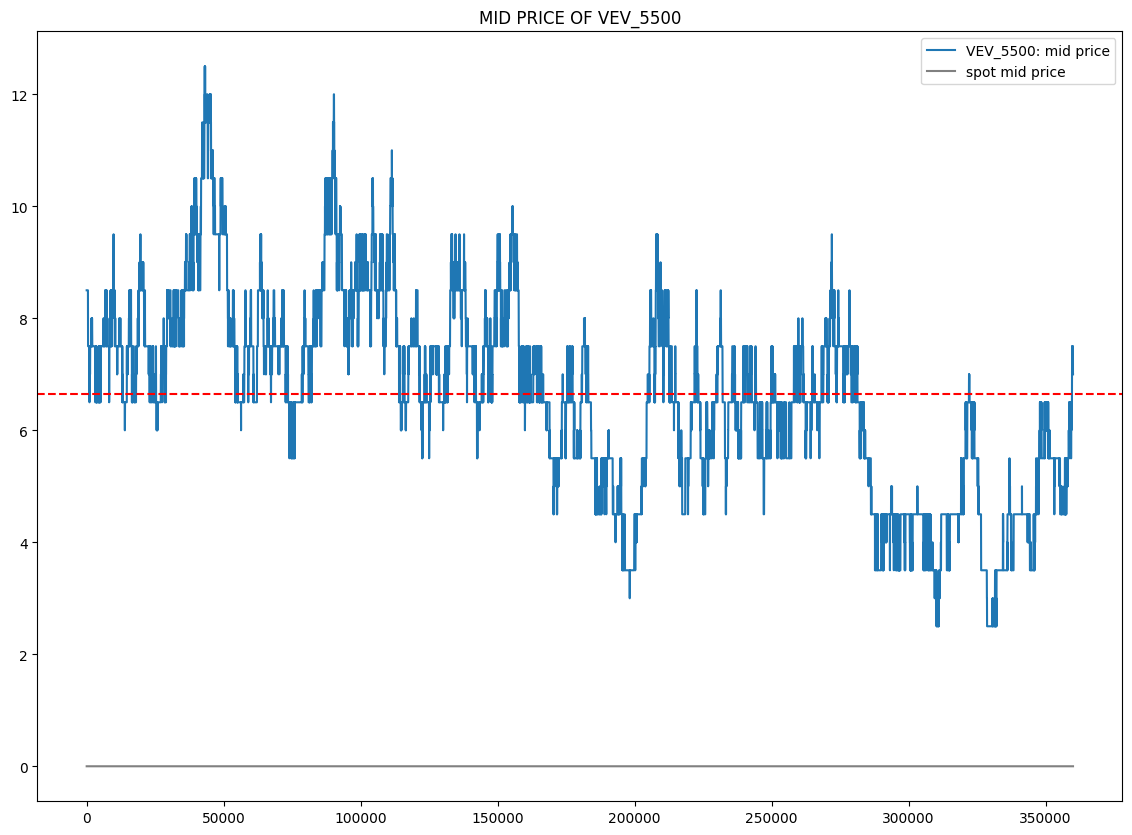

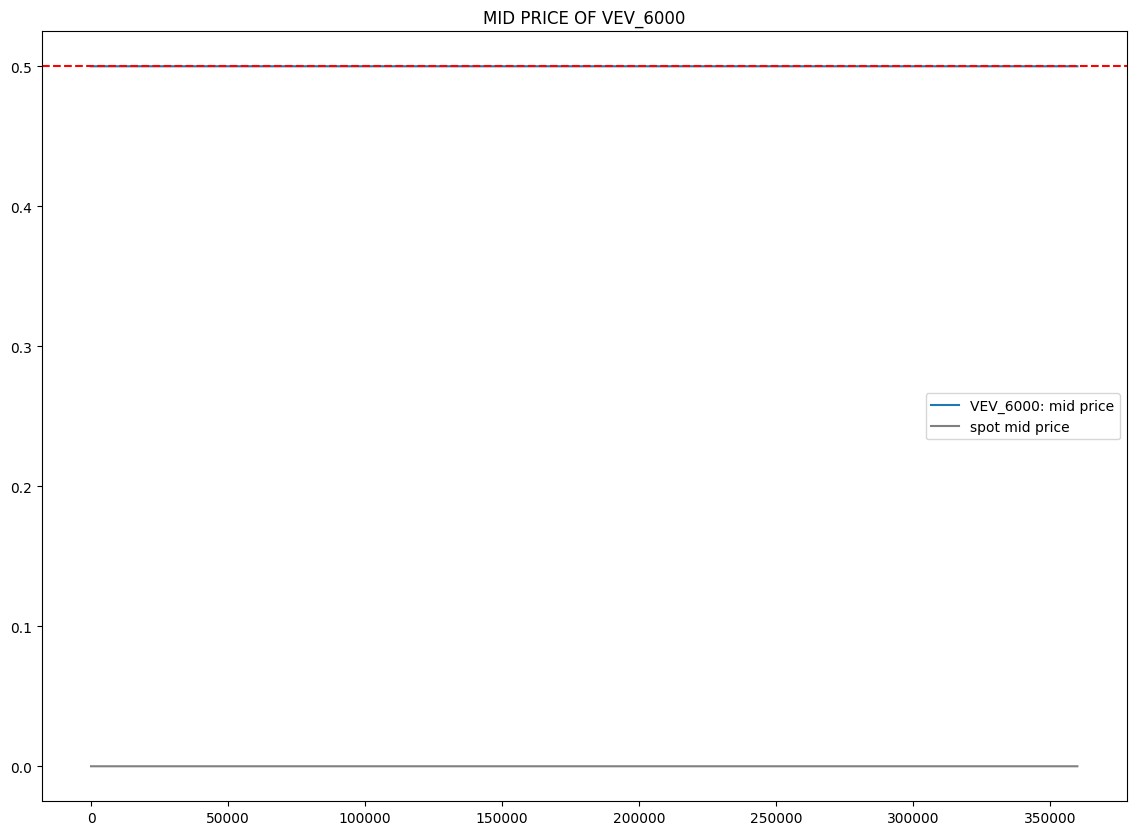

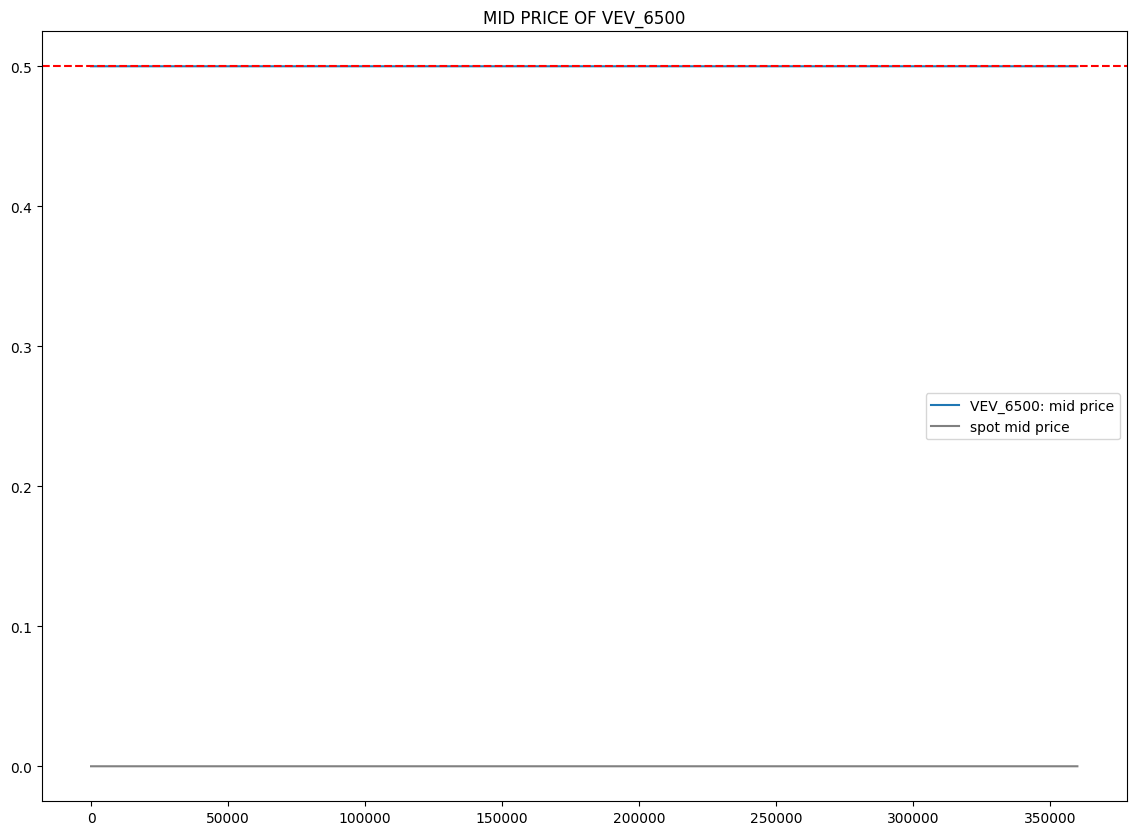

In [ ]:
spot_price = prices_all.loc[prices_all["product"] == "VELVETFRUIT_EXTRACT"]
spot_mid = spot_price["mid_price"]
 

for v_strike in VOUCHER_STRIKE:
    strike = VOUCHER_STRIKE[v_strike]
    v_strike_price = prices_all.loc[prices_all["product"] == v_strike]
    v_strike_mid = v_strike_price["mid_price"]
    v_strike_mid_avg = v_strike_mid.mean()
    
    spot_mid_adjusted = (spot_mid - strike).clip(lower = 0)
    
    
    
    # plot mid
    fig, ax = plt.subplots(1,1, figsize = (14,10))
    ax.plot(v_strike_mid, label = f"{v_strike}: mid price")
    ax.plot(spot_mid_adjusted, label = "spot mid price adjudted by intrinsic", color = "grey")
    ax.plot()
    ax.set_title(f"MID PRICE OF {v_strike}")
    ax.legend()
    ax.axhline(y= v_strike_mid_avg, color='red', linestyle='--', linewidth=1.5)